In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

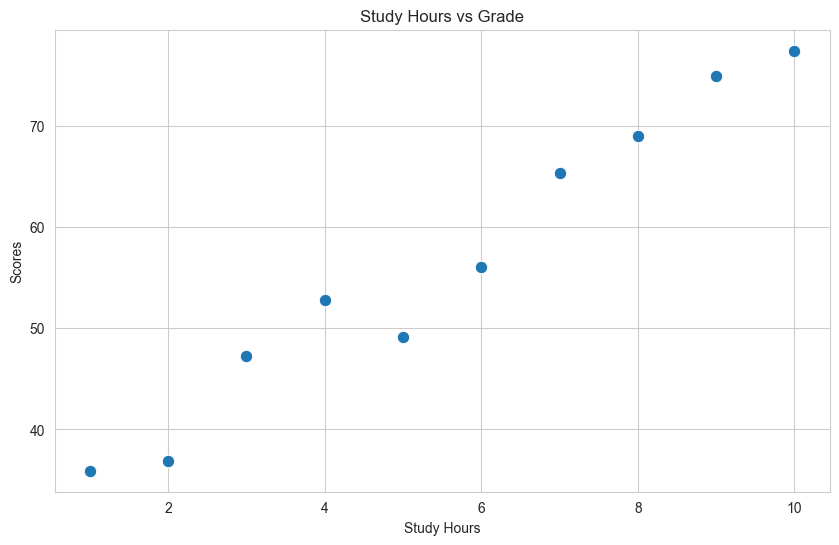

In [2]:
# rng: random number generator
rng = np.random.default_rng(42)

# generate data
max_hours = 10
study_hours = np.arange(1,max_hours+1)
#  y = 30 + 5x + noise
exam_scores = 30 + 5 * study_hours + rng.normal(0, 3, max_hours)

# plot
df = pd.DataFrame({'X': study_hours, 'y': exam_scores})
sns.scatterplot(data=df, x='X', y='y', s=80)
plt.xlabel('Study Hours')
plt.ylabel('Scores')
plt.title('Study Hours vs Grade')
plt.show()

In [4]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 177.7 kB/s eta 0:00:43
   -- ------------------------------------- 0.5/8.1 MB 177.7 kB/s eta 0:00:43
   -- ------------------------------------- 0.5/8.1 MB 177.7 kB/s eta 0:00:43
   -- ------------------------------------- 0.5/8.1 MB 177.7 kB/s eta 0:00:43
   -- ------------------------------------- 0.5/8.1 MB 177.7 kB/s eta 0:00:43
   -- ------------------------------------- 0.5/8.1 MB 177


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from sklearn.model_selection import train_test_split

X = df[['X']] # features must be in a 2D array
y = df['y']   # single target 1D
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3 , random_state=42
)
print(f"X with {len(X_train)} samples (X_train) for training and {len(X_test)} for testing (X_test).")

X with 7 samples (X_train) for training and 3 for testing (X_test).


In [6]:
from sklearn.linear_model import LinearRegression
# Create model instance
model = LinearRegression()
# Train (fit) the model
model.fit(X_train, y_train)
# Print model summary
print(f"Equation: y = {model.intercept_:.2f} + {model.coef_[0]:.2f} * x")

Equation: y = 31.88 + 4.57 * x


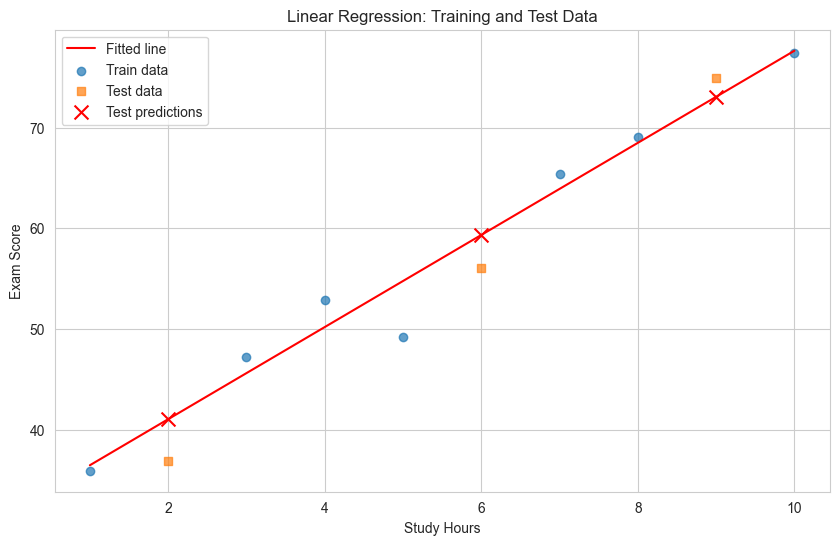

In [7]:
# Plot training and test data
df = pd.concat([
    X_train.assign(y=y_train, set="train"),
    X_test.assign(y=y_test, set="test")
], ignore_index=True)


# Fitted line
plt.plot(X, model.predict(X), 'r-', label='Fitted line')
# Predict on train and test separately
plt.scatter(X_train, y_train, label='Train data', alpha=0.7)
plt.scatter(X_test, y_test, label='Test data', marker='s', alpha=0.7)
# Optional: Mark predictions with X markers
plt.scatter(X_test, model.predict(X_test), marker='x', s=100,
            color='red', label='Test predictions', zorder=5)

# sns.lmplot(x='X', y='y', hue='sample', data=df,
#            #scatter_kws={'s': 80}  ,  # point size
#            ci=95,                    # confidence level
#            aspect=2)

plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Training and Test Data')
plt.legend();

In [8]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Predict on training and test sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate metrics
r2_train = r2_score(y_true=y_train, y_pred=y_train_pred)
r2_test = r2_score(y_true=y_test, y_pred=y_test_pred)

mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)

print("=== Model Performance ===")
print("R² closer to 1 = better fit | Lower MAE/RMSE = smaller errors")
print()
print(f"R²:")
print(f"\tTrain: {r2_train:.3f}")
print(f"\tTest:  {r2_test:.3f}")
print(f"The model explains {r2_test*100:.1f}% of variance in test data.")
print()
print(f"Test Set Errors:")
print(f"\tMAE:  {mae_test:.2f} points")
print(f"\tRMSE: {rmse_test:.2f} points")

=== Model Performance ===
R² closer to 1 = better fit | Lower MAE/RMSE = smaller errors

R²:
	Train: 0.965
	Test:  0.957
The model explains 95.7% of variance in test data.

Test Set Errors:
	MAE:  3.10 points
	RMSE: 3.23 points


# Exercise 1

In [ ]:
# Load diamonds dataset
diamond = sns.load_dataset('diamonds')

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# train/test split
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly, y_poly, test_size=0.3 , random_state=43
)

# Compare different polynomial degrees
degrees = [1, 2, 7, 10]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

X_range = np.linspace(X_poly.min(), X_poly.max(), 100).reshape(-1, 1)

for idx, degree in enumerate(degrees):
    # Create pipeline: PolynomialFeatures -> LinearRegression
    # include_bias=False to avoid redundant intercept

    model_poly = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False), # include_bias=False to avoid redundant intercept
        LinearRegression()
    )
    
    # Train model
    model_poly.fit(X_train_p, y_train_p)
    
    # Evaluate
    r2_train = model_poly.score(X_train_p, y_train_p)
    r2_test = model_poly.score(X_test_p, y_test_p)
    
    # Predict
    y_range_pred = model_poly.predict(X_range)
    
    # Plot
    axes[idx].scatter(X_train_p, y_train_p, alpha=0.5, label='Train', s=50)
    axes[idx].scatter(X_test_p, y_test_p, alpha=0.5, label='Test', s=50, marker='s')
    axes[idx].plot(X_range, y_range_pred, 'r-', linewidth=2, label='Fit')
    axes[idx].set_title(f'Degree {degree}\nR²(train)={r2_train:.3f}, R²(test)={r2_test:.3f}')
    axes[idx].set_xlabel('X')
    axes[idx].set_ylabel('y')
    axes[idx].legend()
    axes[idx].set_ylim([y_poly.min()-10, y_poly.max()+10])

plt.tight_layout()
plt.show()